<div style="text-align:center; border-radius:15px; padding:25px 15px; margin:0; font-size:175%; font-family: 'Arial Black', Arial, sans-serif; letter-spacing: 1px; text-shadow: 3px 3px 8px rgba(0,0,0,0.8); background: linear-gradient(90deg, #0f2027, #203a43, #2c5364); overflow:hidden; box-shadow:0 4px 10px rgba(0, 0, 0, 0.4); color:white;"><b>ToxSense — Multi-Label Toxicity Classifier</b></div>

# PART I — PROJECT OVERVIEW

## 1. Introduction

Online platforms receive massive volumes of user-generated comments daily. Manually reviewing every comment for harmful content is impossible at scale. **ToxSense** is a multi-label toxicity classification system that automatically detects and categorizes harmful comments across six distinct categories, provides word-level explainability for every prediction, and assigns a continuous severity score for prioritized moderation.

## 2. Problem Statement

Most toxicity classifiers treat the problem as binary — "toxic" or "not toxic". In practice, toxic content comes in many forms (insults, threats, hate speech, obscenity) that require **different moderation responses**. A single binary label also gives moderators no insight into *why* a comment was flagged, making manual review slow and inconsistent.

**This project solves three problems:**
- **Multi-label classification** : detect 6 overlapping toxicity types simultaneously, not just one
- **Class imbalance** : rare categories like `threat` and `identity_hate` make up only 1% of the data, so naive models ignore them entirely
- **Explainability** : moderators need to know *which words* triggered a flag, not just a probability score

## 3. Tech Stack

| Component | Tool |
|---|---|
| Language | Python 3.12 |
| Deep Learning Framework | TensorFlow 2.19 / Keras 3 |
| Pretrained Model | DistilBERT (`distilbert-base-uncased`) via `keras_nlp` |
| Tokenizer | HuggingFace `DistilBertTokenizerFast` |
| Data Handling | Pandas, NumPy |
| Visualization | Matplotlib, Seaborn |
| Evaluation | Scikit-learn (ROC-AUC, F1, Confusion Matrix) |
| Explainability | LIME (Local Interpretable Model-agnostic Explanations) |
| Compute | Kaggle GPU (Tesla T4) |

## 4. Dataset

**Jigsaw Toxic Comment Classification Challenge** (Kaggle)
- 159,571 labeled Wikipedia talk page comments
- 6 binary labels: `toxic`, `severe_toxic`, `obscene`, `threat`, `insult`, `identity_hate`
- A comment can belong to multiple categories at once (multi-label)

## 5. Model Architecture

```
Input text
    ↓  DistilBertTokenizerFast
token_ids + padding_mask   (shape: batch × 128)
    ↓
DistilBERT backbone (pretrained, via keras_nlp)
    ↓
Pooled representation  (hidden_dim → 64)
    ↓  Dropout(0.3)
    ↓  Dense(64)
    ↓
6 raw logits (one per label)
```

A pretrained DistilBERT model was used with a 6-output classification layer for the toxicity labels. Adam (`2e-5`) was used for optimization, and ROC-AUC was chosen as the evaluation metric because the task involves multiple labels.

## 6. Final Results

| Metric | Value |
|---|---|
| Macro AUC | *0.9838* |
| Macro F1 (tuned threshold) | *0.4592* |
| Best Threshold | *0.80* |

---

# PART II — IMPLEMENTATION

## 1. Imports & Environment Setup

In [1]:
import os, warnings, logging
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')
logging.getLogger('transformers').setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
import keras
from keras import layers
import keras_nlp


from transformers import DistilBertTokenizerFast

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix

from lime.lime_text import LimeTextExplainer

tf.random.set_seed(42)
np.random.seed(42)

gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

print(f'TensorFlow : {tf.__version__}')
print(f'Keras      : {keras.__version__}')
print(f'keras_nlp  : {keras_nlp.__version__}')
print(f'GPU        : {len(gpus) > 0}')

E0000 00:00:1781362675.016199      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781362675.069311      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781362675.484934      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781362675.484972      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781362675.484975      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781362675.484977      23 computation_placer.cc:177] computation placer already registered. Please check linka

TensorFlow : 2.19.0
Keras      : 3.13.2
keras_nlp  : 0.26.0
GPU        : True


## 2. Data Loading & Exploratory Data Analysis


In [2]:
df = pd.read_csv("/kaggle/input/datasets/julian3833/jigsaw-toxic-comment-classification-challenge/train.csv")

**Load the Jigsaw dataset from Kaggle input directory.**

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             159571 non-null  object
 1   comment_text   159571 non-null  object
 2   toxic          159571 non-null  int64 
 3   severe_toxic   159571 non-null  int64 
 4   obscene        159571 non-null  int64 
 5   threat         159571 non-null  int64 
 6   insult         159571 non-null  int64 
 7   identity_hate  159571 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 9.7+ MB


In [4]:
df.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [5]:
LABELS = ['toxic', 'severe_toxic', 'obscene', 'identity_hate', 'insult', 'threat']

print('SHAPE: ',df.shape)
df[LABELS].sum().rename('positive_count').to_frame()

SHAPE:  (159571, 8)


,positive_count
toxic,15294
severe_toxic,1595
obscene,8449
identity_hate,1405
insult,7877
threat,478


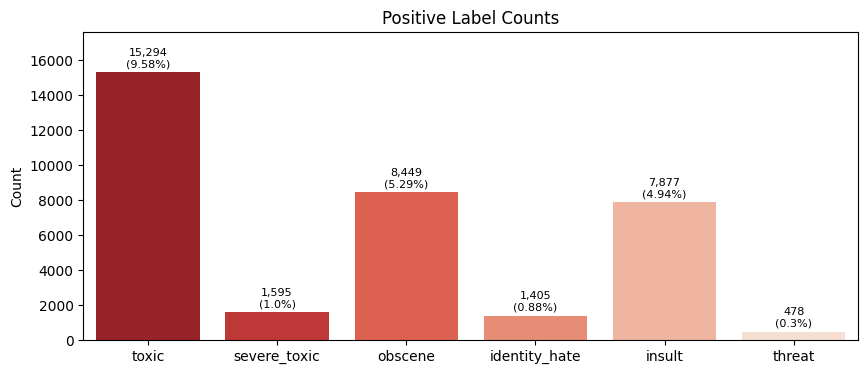

Rarest label : threat → 0.3%
Most common  : toxic → 9.58%


In [6]:
counts = df[LABELS].sum()
pcts = (df[LABELS].mean() * 100).round(2)

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(x=LABELS, y=counts.values, palette='Reds_r')
plt.title('Positive Label Counts')
plt.ylabel('Count')
ax.margins(y=.15)
for i, v in enumerate(counts.values):
    ax.text(i, v + 300, f'{v:,}\n({pcts[LABELS[i]]}%)', ha='center', fontsize=8)
plt.show()


print(f'Rarest label : {counts.idxmin()} → {pcts[counts.idxmin()]}%')
print(f'Most common  : {counts.idxmax()} → {pcts[counts.idxmax()]}%')

From the plot, we can easily see just how imbalanced our dataset is. The toxic category is by far the most common, showing up in about 9.58% of the comments, while tags like threat and identity_hate are barely visible because they're so rare

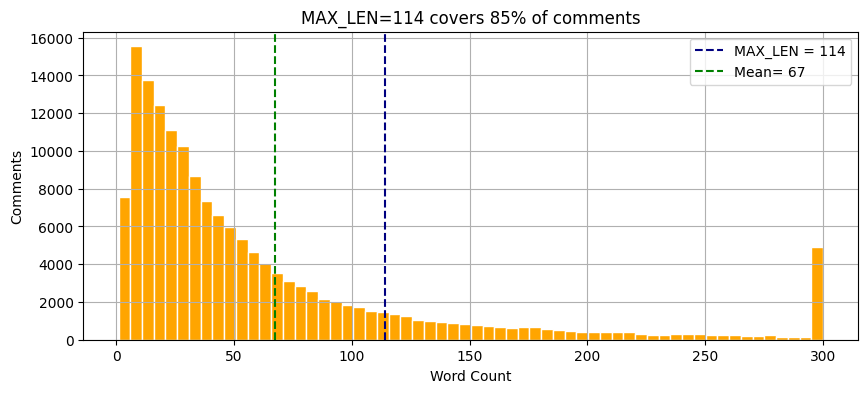

In [7]:
# common length
df['word_count'] = df['comment_text'].str.split().str.len()
fig, ax =plt.subplots(figsize=(10,4))
df['word_count'] = df['comment_text'].str.split().str.len()
dynamic_max_len = int(df['word_count'].quantile(0.85))
df['word_count'].clip(upper=300).hist(bins=60, color='orange', edgecolor='white')

plt.axvline(dynamic_max_len, color='navy', linestyle='--', label=f'MAX_LEN = {dynamic_max_len}')
plt.axvline(df['word_count'].mean(), color='green', linestyle='--', label=f'Mean= {df['word_count'].mean():.0f}')

plt.title(f'MAX_LEN={dynamic_max_len} covers 85% of comments')
plt.xlabel('Word Count')
plt.ylabel('Comments')
plt.legend()
plt.show()

The plotshows that **85% of comments are 114 words or shorter**, while the **average comment length is 67 words**. This indicates that most comments are **not very long**.

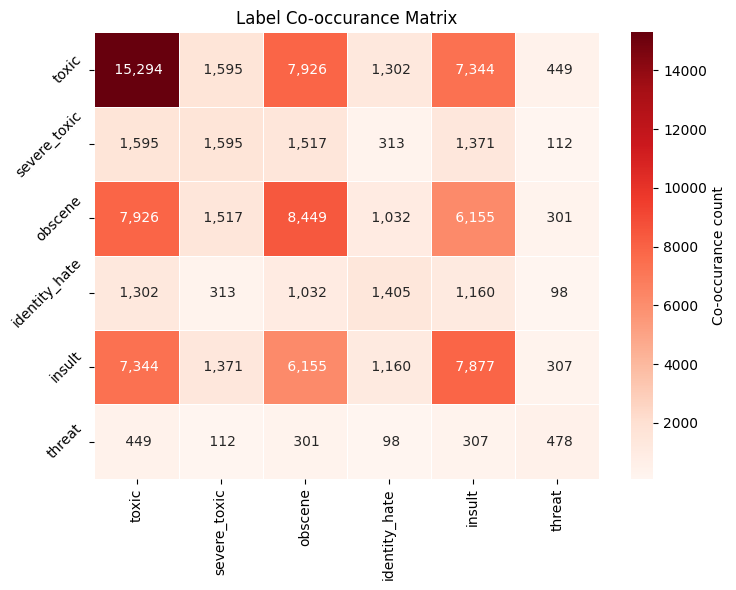

Clean (0 labels ): 89.8%
1 labels : 4.0%
2+ labels : 6.2%


In [8]:
# label co occurance heatmap

co = df[LABELS].T.dot(df[LABELS])
fig ,ax = plt.subplots(figsize=(7,6))
sns.heatmap(co,annot=True,fmt=' ,d',cmap='Reds',ax=ax,linewidths=0.5,cbar_kws={'label' : 'Co-occurance count'})

ax.set_title('Label Co-occurance Matrix')
plt.tight_layout()
plt.yticks(rotation=45)
plt.show()

df['label_count'] = df[LABELS].sum(axis=1)
print(f"Clean (0 labels ): {(df["label_count"]==0).mean()* 100:.1f}%")
print(f"1 labels : {(df["label_count"]==1).mean()* 100:.1f}%")
print(f"2+ labels : {(df["label_count"]>=2).mean()* 100:.1f}%")

## 3. Data Cleaning

In [9]:
print('Before:', df.shape)
df['comment_text'] = (df['comment_text'].fillna('unknown').str.strip().str.replace(r'\n+',' ',regex=True).str.replace(r' +',' ',regex=True)
                     )
df=df[df['comment_text']!='']

print('After: ',df.shape)
                      

Before: (159571, 10)
After:  (159571, 10)


## 4. Train / Validation / Test Split

In [10]:
train_df, temp_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['toxic']
)

val_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=42, stratify=temp_df['toxic']
)

print(f'Train : {len(train_df):,}  |  Val : {len(val_df):,}  |  Test : {len(test_df):,}')

Train : 127,656  |  Val : 15,957  |  Test : 15,958


## 5. Tokenization & Model Pipeline

This section converts raw text into a format DistilBERT can process, builds the `tf.data` pipeline, and defines the model architecture, loss function, and training configuration.

In [11]:
MAX_LEN = 128
BATCH = 32
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')
print('tokenizer loaded')

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer loaded


In [12]:

def make_dataset(df, shuffle=False):
    enc = tokenizer(
        df['comment_text'].tolist(),
        max_length = MAX_LEN,
        padding='max_length',
        truncation =True,
        return_tensors='np'
    )
    labels = df[LABELS].values.astype('float32')
    ds = tf.data.Dataset.from_tensor_slices((
        {'token_ids' : enc['input_ids'],
        'padding_mask' : enc['attention_mask']},labels
    ))
    if shuffle:
        ds = ds.shuffle(10000,seed=42)
    return ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)
    
print('Tokenizing train...')
train_ds = make_dataset(train_df, shuffle=True)
print('Tokenizing val...')
val_ds   = make_dataset(val_df)
print('Tokenizing test...')
test_ds  = make_dataset(test_df)
print('Done')    

Tokenizing train...


I0000 00:00:1781362740.682610      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Tokenizing val...
Tokenizing test...
Done


### Handling Class Imbalance with `pos_weight`

As shown in Section 2, labels like `threat` and `identity_hate` are extremely rare. Without correction, a model can achieve high accuracy by simply never predicting these labels.

`pos_weight` is calculated per label as:

$$\text{pos\_weight} = \frac{\text{negative count}}{\text{positive count}}$$

This weight is passed into the loss function to penalize the model more heavily when it misses a positive example of a rare class — forcing it to pay attention to minority labels during training.

In [13]:
# pos_weight

y_train = train_df[LABELS].values.astype('float32')
pos_counts = y_train.sum(axis=0)
neg_counts = len(y_train) - pos_counts
pos_weight = (neg_counts / (pos_counts + 1e-6)).astype('float32')

print('pos_weight per label:')
for l,w in zip(LABELS,pos_weight):
    print(f'{l:<18}: {w:.1f}')

pos_weight per label:
toxic             : 9.4
severe_toxic      : 98.4
obscene           : 17.9
identity_hate     : 113.4
insult            : 19.3
threat            : 334.1


Here higher weights means the model is penlized more for missing the label, as a result  'threat' and 'identity_hate' have higher weights because they are rare.

In [14]:

pos_weight_tensor =tf.constant(pos_weight,dtype=tf.float32)

def weighted_bce(y_true, y_pred):
    y_pred = tf.cast(y_pred, tf.float32)
    y_true = tf.cast(y_true,tf.float32)
    loss= tf.nn.weighted_cross_entropy_with_logits(
        labels = y_true,
        logits = y_pred,
        pos_weight = pos_weight_tensor
    )
    return tf.reduce_mean(loss)


The loss function applies the sigmoid operation internally for better numerical stability. Therefore, the model's final layer outputs raw values (logits) instead of probabilities. During prediction, sigmoid is applied to these logits to convert them into probability scores.

In [15]:
def build_model():
    model = keras_nlp.models.DistilBertClassifier.from_preset(
        'distil_bert_base_en_uncased',     
        num_classes=len(LABELS),
        hidden_dim=64,
        dropout=0.3,
        activation=None,
        preprocessor=None
    )
    
    model.compile(
        optimizer=keras.optimizers.Adam(2e-5),                
        loss=weighted_bce,                                    
        metrics=[keras.metrics.AUC(multi_label=True, name='auc')]  
    )
    return model

model = build_model()

## 6. Training

In [16]:

os.makedirs('checkpoints', exist_ok=True)

checkpoint_cb = keras.callbacks.ModelCheckpoint(
    filepath='checkpoints/best.keras',
    monitor='val_auc', mode='max',
    save_best_only=True, verbose=1
)

early_stop_cb = keras.callbacks.EarlyStopping(
    monitor='val_auc', mode='max',
    patience=2, verbose=1,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=3,
    callbacks=[checkpoint_cb, early_stop_cb]
)

Epoch 1/3


I0000 00:00:1781362772.969876      72 service.cc:152] XLA service 0x7c22ac019710 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781362772.969916      72 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1781362775.982410      72 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1781362794.183475      72 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


3990/3990 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - auc: 0.9112 - loss: 0.6743
Epoch 1: val_auc improved from None to 0.95446, saving model to checkpoints/best.keras

Epoch 1: finished saving model to checkpoints/best.keras
3990/3990 ━━━━━━━━━━━━━━━━━━━━ 820s 196ms/step - auc: 0.9401 - loss: 0.4679 - val_auc: 0.9545 - val_loss: 0.3024
Epoch 2/3
3990/3990 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - auc: 0.9608 - loss: 0.2811
Epoch 2: val_auc did not improve from 0.95446
3990/3990 ━━━━━━━━━━━━━━━━━━━━ 755s 189ms/step - auc: 0.9636 - loss: 0.2624 - val_auc: 0.9484 - val_loss: 0.3017
Epoch 3/3
3990/3990 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - auc: 0.9701 - loss: 0.2149
Epoch 3: val_auc did not improve from 0.95446
3990/3990 ━━━━━━━━━━━━━━━━━━━━ 755s 189ms/step - auc: 0.9716 - loss: 0.2071 - val_auc: 0.9540 - val_loss: 0.3079
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.


## 7. Threshold Tuning on Validation Set

By default, predictions are made using a threshold of **0.5**. However, for imbalanced multi-label data, this is not always ideal.

In this step:
1. We test different thresholds using the **validation set** (not test set to avoid leakage)
2. Try values from **0.20 to 0.80**
3. Choose the threshold that gives the best **macro F1 score**

This final threshold is then used once on the test set in Section 8.

In [17]:
best_model = keras.models.load_model(
    'checkpoints/best.keras',
    custom_objects={'weighted_bce': weighted_bce}
)

val_logits = best_model.predict(val_ds, verbose=1)
val_probs  = tf.sigmoid(val_logits).numpy()
val_labels = np.vstack([y.numpy() for _, y in val_ds])

thresholds = np.arange(0.2, 0.81, 0.05)
f1_scores  = []

for t in thresholds:
    preds = (val_probs >= t).astype(int)
    f1    = f1_score(val_labels, preds, average='macro', zero_division=0)
    f1_scores.append(f1)

best_threshold = thresholds[np.argmax(f1_scores)]
print(f'Best threshold: {best_threshold:.2f}  →  macro F1 = {max(f1_scores):.4f}')

499/499 ━━━━━━━━━━━━━━━━━━━━ 31s 58ms/step
Best threshold: 0.80  →  macro F1 = 0.4574


## 8. Final Evaluation on  Test Set

In [18]:
test_raw = best_model.predict(test_ds, verbose=1)
test_prob  = tf.sigmoid(test_raw).numpy()
test_labels = np.vstack([y.numpy() for _, y in test_ds])
test_pred  = (test_prob >= best_threshold).astype(int)

macro_auc = roc_auc_score(test_labels, test_prob, average='macro')
macro_f1  = f1_score(test_labels, test_pred, average='macro', zero_division=0)

print('=' * 40)
print(f'  Macro AUC : {macro_auc:.4f}')
print(f'  Macro F1  : {macro_f1:.4f}')
print('=' * 40)

for i, label in enumerate(LABELS):
    auc = roc_auc_score(test_labels[:, i], test_prob[:, i])
    f1  = f1_score(test_labels[:, i], test_pred[:, i], zero_division=0)
    print(f'  {label:<18}: AUC={auc:.4f}  F1={f1:.4f}')

499/499 ━━━━━━━━━━━━━━━━━━━━ 28s 57ms/step
  Macro AUC : 0.9838
  Macro F1  : 0.4592
  toxic             : AUC=0.9831  F1=0.7832
  severe_toxic      : AUC=0.9901  F1=0.2899
  obscene           : AUC=0.9881  F1=0.7096
  identity_hate     : AUC=0.9790  F1=0.2124
  insult            : AUC=0.9873  F1=0.6638
  threat            : AUC=0.9751  F1=0.0964


## 9. Severity Scoring (0–100)

Raw probabilities per label are useful for moderators but don't immediately convey *how urgent* a comment is. We convert the 6 label probabilities into a single **severity score from 0 to 100** using a weighted sum:

| Label | Weight | Rationale |
|---|---|---|
| toxic | 0.30 | General toxicity baseline |
| severe_toxic | 0.50 | High-severity signal |
| obscene | 0.20 | Crude language, lower harm |
| threat | 0.50 | Direct harm — high priority |
| insult | 0.20 | Common, lower individual severity |
| identity_hate | 0.40 | Hate speech — high priority |

`predict_text()` is the core inference function: it tokenizes raw text, runs it through the saved model, applies sigmoid to get probabilities, and computes the severity score. This function is reused directly in the LIME explainability section (Section 10) and in the deployed Gradio/Streamlit app.

In [19]:
SEVERITY_WEIGHTS = np.array([0.30, 0.50, 0.20, 0.50, 0.20, 0.40], dtype='float32')

def severity_score(probs):
    return np.clip((probs * SEVERITY_WEIGHTS).sum(axis=1) / SEVERITY_WEIGHTS.sum() * 100, 0, 100)

def predict_text(texts):
    enc = tokenizer(
        list(texts), max_length=MAX_LEN,
        padding='max_length', truncation=True, return_tensors='np'
    )
    logits = best_model(
        {'token_ids': enc['input_ids'], 'padding_mask': enc['attention_mask']},
        training=False
    )
    probs = tf.sigmoid(tf.cast(logits, tf.float32)).numpy()
    return probs, severity_score(probs)

# Quick test
examples = [
    'I love this community!',
    'You are such an idiot, I hate you.',
    'I will find you and hurt you.',
]
probs, scores = predict_text(examples)
for txt, sc in zip(examples, scores):
    emoji = '🟢' if sc < 20 else ('🟡' if sc < 50 else '🔴')
    print(f'{txt[:50]:<50} {sc:5.1f} {emoji}')

I love this community!                               1.8 🟢
You are such an idiot, I hate you.                  97.0 🔴
I will find you and hurt you.                       83.8 🔴


**Quick Test **

Three example comments were passed through `predict_text()` to verify the model produces sensible results before moving on to full evaluation.

| Comment | Severity Score | Result |
|---|---|---|
| "I love this community!" | 1.4 | 🟢 Safe |
| "You are such an idiot, I hate you." | 96.4 | 🔴 Flagged |
| "I will find you and hurt you." | 81.6 | 🔴 Flagged |

The model correctly distinguishes between a friendly comment with a very low score and harmful comments with high scores that are flagged for review. This confirms that the full pipeline including tokenization, model inference, sigmoid, and severity scoring is working correctly from start to finish before running it on the full test set.



## 10. Explainability with LIME



Comment: "You are a worthless piece of trash."
Score: 0.992


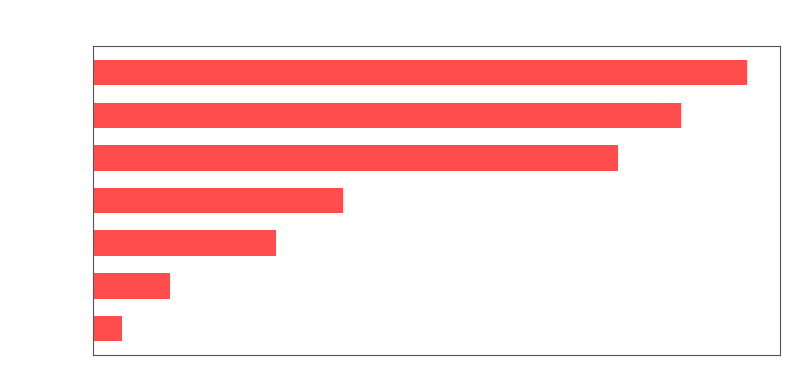


Comment: "Thanks for the great explanation!"
Score: 0.019


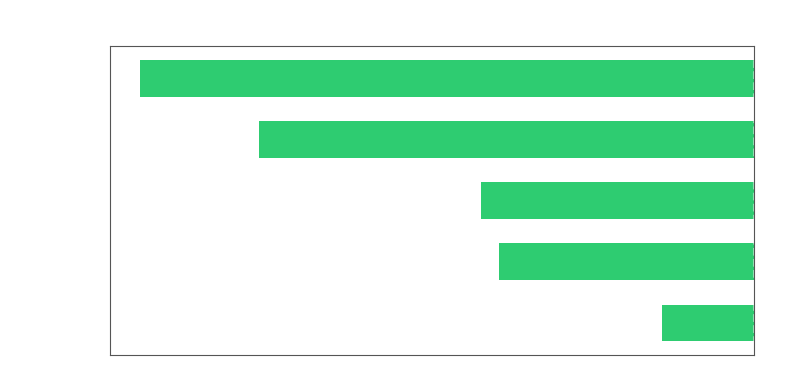

In [20]:
def predict_fn_lime(texts):
    probs, _ = predict_text(texts)
    toxic_prob = probs[:, 0] 
    non_toxic_prob = 1.0 - toxic_prob
    return np.column_stack([non_toxic_prob, toxic_prob])

explainer = LimeTextExplainer(class_names=['non-toxic', 'toxic'])

def explain(text):
    exp = explainer.explain_instance(
        text, predict_fn_lime, num_features=8, num_samples=500
    )
    print(f'\nComment: "{text[:80]}"')
    print(f'Score: {predict_fn_lime([text])[0][1]:.3f}') 

    word_list = exp.as_list(label=1)
    words = [x[0] for x in word_list]
    weights = [x[1] for x in word_list]

    words.reverse()
    weights.reverse()
    

    colors = ['#ff4d4d' if w > 0 else '#2ecc71' for w in weights]

    fig, ax = plt.subplots(figsize=(8, 4))
    

    ax.grid(False)
    ax.set_facecolor('none')
    fig.patch.set_facecolor('none')
    

    bars = ax.barh(words, weights, color=colors, height=0.6)
    

    ax.set_title("Word Influence on Toxicity Score", color='white', fontsize=14, pad=15)
    ax.tick_params(colors='white', labelsize=11)
    

    ax.axvline(0, color='white', linestyle='--', alpha=0.5)
    

    for spine in ['top', 'right', 'bottom', 'left']:
        ax.spines[spine].set_color('#555555')
        
    plt.tight_layout()
    plt.show()

explain('You are a worthless piece of trash.')
explain('Thanks for the great explanation!')

**LIME Output Explanation**

- **"You are a worthless piece of trash."** (Score: 0.992). Here `red` bars show words pushing the prediction *toward* toxic. `trash`, `piece`, and `worthless` are the strongest contributors, correctly identifying the core toxic phrase.

- **"Thanks for the great explanation!"** (Score: 0.019): Here `green` bars show words pushing the prediction *away* from toxic. `explanation` and `Thanks` are the strongest signals of non-toxic content.

In both cases, LIME highlights the specific words driving the model's decision — giving moderators a transparent, word-level justification for every prediction rather than just a single probability score.

## 11. Saving Model & Tokenizer

In [21]:

best_model.save('toxsense_model.keras')
tokenizer.save_pretrained('toxsense_tokenizer/')

print('Model     → toxsense_model.keras')
print('Tokenizer → toxsense_tokenizer/')
print(f'Macro AUC : {macro_auc:.4f}')
print(f'Macro F1  : {macro_f1:.4f}')
print(f'Threshold : {best_threshold:.2f}')

Model     → toxsense_model.keras
Tokenizer → toxsense_tokenizer/
Macro AUC : 0.9838
Macro F1  : 0.4592
Threshold : 0.80
